# Visualize Shanghai Radar data

In [1]:
import torch
import h5py
import numpy as np
from torch.utils.data import Dataset
from torchvision import transforms 
from matplotlib import colors
from src.data_shanghai import Shanghai, gray2color
import matplotlib.pyplot as plt

In [2]:
PIXEL_SCALE = 90.0

COLOR_MAP = np.array([
    [0, 0, 0,0],
    [0, 236, 236, 255],
    [1, 160, 246, 255],
    [1, 0, 246, 255],
    [0, 239, 0, 255],
    [0, 200, 0, 255],
    [0, 144, 0, 255],
    [255, 255, 0, 255],
    [231, 192, 0, 255],
    [255, 144, 2, 255],
    [255, 0, 0, 255],
    [166, 0, 0, 255],
    [101, 0, 0, 255],
    [255, 0, 255, 255],
    [153, 85, 201, 255],
    [255, 255, 255, 255]
    ]) / 255

BOUNDS = [0,5,10,15,20,25,30,35,40,45,50,55,60,65,70,75, PIXEL_SCALE]
THRESHOLDS = [20, 30, 35, 40]

HMF_COLORS = np.array([
    [82, 82, 82],
    [252, 141, 89],
    [255, 255, 191],
    [145, 191, 219]
]) / 255

/pscratch/sd/p/puren93/miniforge3.bak-20250811-1035/envs/sft/lib/python3.10/site-packages/torchvision/transforms/functional.py:1603: UserWarning: The default value of the antialias parameter of all the resizing transforms (Resize(), RandomResizedCrop(), etc.) will change from None to True in v0.17, in order to be consistent across the PIL and Tensor backends. To suppress this warning, directly pass antialias=True (recommended, future default), antialias=None (current default, which means False for Tensors and True for PIL), or antialias=False (only works on Tensors - PIL will still use antialiasing). This also applies if you are using the inference transforms from the models weights: update the call to weights.transforms(antialias=True).
  warnings.warn(


1545
torch.Size([25, 1, 128, 128]) torch.Size([25, 1, 128, 128])
tensor(0.) tensor(0.8307)
tensor(0.) tensor(0.7082)


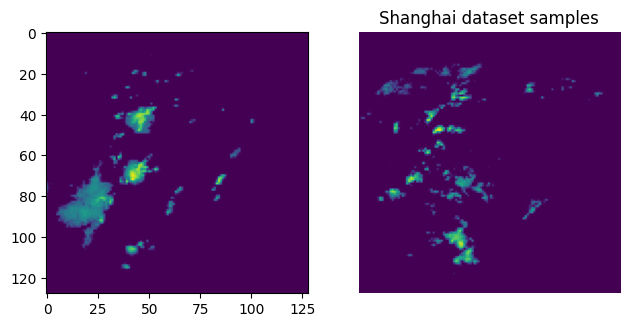

In [ ]:
data_path = "/global/cfs/cdirs/m4633/puren/interp_dm/shanghai/"
dataset = Shanghai(data_path + 'shanghai.h5', 128)
sample1 = dataset.sample()
sample2 = dataset.sample()

print(len(dataset))
print(sample1.shape, sample2.shape)
print(sample1.min(), sample1.max())
print(sample2.min(), sample2.max())
# print(sample1[0,0].numpy())

# plt.subplot(1,2,1)
# plt.imshow(sample1[10,0].numpy())
# plt.subplot(1,2,2)
# plt.imshow(sample2[10,0].numpy())
# # plt.title('Shanghai dataset samples')
# plt.tight_layout()
# # plt.axis('off')
# plt.colormaps()
# plt.show()
# # plt.savefig('sample.png')

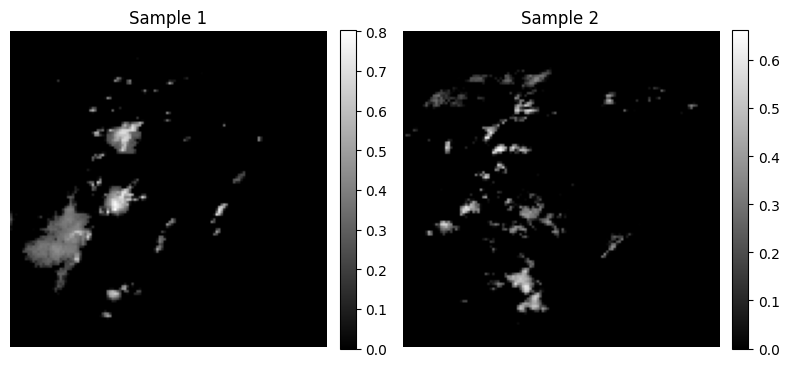

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
cmap = 'gray' # 'turbo' # 'viridis' #  

# First subplot
im1 = axes[0].imshow(sample1[10, 0].numpy(), cmap=cmap)
axes[0].set_title('Sample 1')
axes[0].axis('off')
fig.colorbar(im1, ax=axes[0], fraction=0.046, pad=0.04)

# Second subplot
im2 = axes[1].imshow(sample2[10, 0].numpy(), cmap=cmap)
axes[1].set_title('Sample 2')
axes[1].axis('off')
fig.colorbar(im2, ax=axes[1], fraction=0.046, pad=0.04)

plt.tight_layout()
# plt.savefig('sample.png', dpi=300, bbox_inches='tight')
plt.show()

In [12]:
# fig, axes = plt.subplots(1, 2, figsize=(8, 4))

# # First subplot
# im1 = axes[0].imshow(gray2color(sample1[10, 0].numpy()), cmap='viridis')
# axes[0].set_title('Sample 1')
# axes[0].axis('off')
# fig.colorbar(im1, ax=axes[0], fraction=0.046, pad=0.04)

# # Second subplot
# im2 = axes[1].imshow(gray2color(sample2[10, 0].numpy()), cmap='viridis')
# axes[1].set_title('Sample 2')
# axes[1].axis('off')
# fig.colorbar(im2, ax=axes[1], fraction=0.046, pad=0.04)

# plt.tight_layout()
# # plt.savefig('sample.png', dpi=300, bbox_inches='tight')
# plt.show()